# Drilling Activity Prediction: Data Modelling - ARIMA

## What is Arima:

**Autoregressive Integrated Moving Average (ARIMA)** are a class of statisical models used to analyze time-series data for analysis and forecasting. ARIMA strips away non-stationary elements via differencing, capturing correlation with past values using autoregression, and utilizes moving averages of past errors to model sudden system shocks. This is all meant to determine temporal structures (dependencies, trends and shocks); evident in historical values to predict fruture values

ARIMA is dependent on three parameters: `ARIMA(p,d,q)`. Each one encapsulates a mathematical operation to identify properties of time-series data.

### 1. Integrated Component $d$ (Differencing)

Real world data (such as stock prices) often show an inflation factor - a trend over time that is external to the component's data. Because of this, data tends to drift (**Data Drift**) and is more difficult to model. We can remove this factor by making the time-series data **Non-stationary**, removing external trends over time - thus we can isolate the inherent true trend of the data. 

Stationary data is evident by it's constant statistical properties - mean, variance and autocorrelation. The integrated (`d`) component converts non-stationary data to stationary by taking the differences of ith data point to `d`. 

**First Order Differencing** is the difference of data points against time as: 

$y'_{t} = y_t - y_{t-1}$

**Second Order Differencing** is the difference of the differences (first order) of the points:

$y''_t = y'_t - y'_{t-1} = (yt-y_{t-1}) - (y_{t-1} - y_{t-2}) = y_t = 2y_{t-1} + y_{t-2}$

### 2. Autoregressive Component: $p$ (Lagged Values)

This is essentially the look back value -> how many units in the time-scale are you going to look back. However, this assumes that staitonary series $(y'_t)$ depends linearly on its own past (lagged) values. You can set the degree of look back with `p`. 

$AR(p)$ is modelled as
$y'_t = c + \phi_{1y'_{t-1}} + \phi_{2y'_{t-2}} + ... + \phi_{p2'_{t-p}} + \epsilon_t$

Where: 
* $c$ is the constant term (intercept)
* $\phi_1 ... $\phi_p$ are the coefficients to be estimated
* \epsilon_t is white noise (random error at time t)

### 3. Moving Average Component: $q$ (Lagged Errors)

Measures the residual deviations from the mean -> which models the current value of the series as a linear combination of past forecast errors (shocks). 

$y'_t = \mu + \epsilon_t + \phi_1\epsilon_{t-1} + \phi_2epsilon_{t-2} + ... + \phi_q\epsilon_{t-q}$

Where:
* $\mu$ is the expectation of the series
* $\phi_1, ... \phi_q$ are the error wieght parameters to be estimated
* $\epsilon_{t-1},...\epsilon_{t-q}$ are the historical residuals (actual value minus predicted value).

### Combined ARIMA Equation

Mathematical equation for a stationary series modelled by $ARIMA(p,q,d)$ is expressed using backshift notation $(By_t = y_{t-1})$ as: 

$(1- \sum_{i=1}^{p}\phi_iB^i)(1-B)^dy_t = c + (1+\sum_{j=1}^{q}\phi_jB^j)\epsilon_t$

In [21]:
import duckdb
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_colwidth', None)

# Load specific forecasting tools
from statsmodels.tsa.arima.model import ARIMA,ARIMAResults
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tools.eval_measures import rmse, mse, meanabs
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.stats.diagnostic import acorr_ljungbox
import time
from pmdarima import auto_arima
from pylab import rcParams

from pathlib import Path

# Ignore harmless warnings
import warnings
warnings.filterwarnings("ignore")

# Size of all plots
rcParams['figure.figsize'] = 6,6

from itertools import product

In [3]:
conn = duckdb.connect()

# DuckDB connection to PostgreSQL
conn.execute("INSTALL postgres")
conn.execute("LOAD postgres")

# Attach to PostgreSQL database directly
conn.execute(f"""
    ATTACH '
            host={os.getenv("POSTGRES_HOST")} 
            port={os.getenv("POSTGRES_PORT", 5432)} 
            dbname={os.getenv("POSTGRES_DB")}
            user={os.getenv("POSTGRES_USER")}
            password={os.getenv("POSTGRES_PASSWORD")}
            '
    AS pg (TYPE postgres)
""")


In [4]:
oil_ml_set = conn.sql("""
    SELECT 
        * 
    FROM pg.silver.t_oil_ml_set
    ORDER BY period ASC;
""")

oil_ml_set = oil_ml_set.to_df().set_index("period")


In [5]:
gas_ml_set = conn.sql("""
    SELECT 
        * 
    FROM pg.silver.t_gas_ml_set
    ORDER BY period ASC;
""")

gas_ml_set = gas_ml_set.to_df().set_index("period")

Approach to ARIMA:

1. ADF test             -> determine d (stationary requirement)
2. auto_arima (AICc)    -> determine p and q given fixed d
3. Walk-forward CV      -> validate the chosen (p,d,q) generalises
4. Refit on 100%        -> deploy for forecast

## Data Fitting

### Oil Rig Count Modelling

In [9]:
oil_rig_count = conn.sql(
    Path("../src/feature_engineering_sql_scripts/oil_features/oil_rigs.sql").read_text()
).fetchone()[0].lower()

In [10]:
# What are the attributes of the dataset?
series_mapping_gas = conn.sql(f"""
    SELECT 
        LOWER(msn) AS msn
        ,series_description
        ,unit
    FROM pg.silver.v_total_energy_series
    WHERE msn IN ({", ".join([f"'{col.upper()}'" for col in gas_ml_set.columns])})
    """)

display(series_mapping_gas.df())

,msn,series_description,unit
0,ngtwpus,"Wells Drilled, Natural Gas in Number",Number
1,mmiceus,"Motor Gasoline, Excluding Ethanol, Industrial Sector CO2 Emissions in Million Metric Tons of Carbon Dioxide",Million Metric Tons of Carbon Dioxide
2,mgwhuus,Average Refiner Price of Finished Motor Gasoline for Resale in Dollars per Gallon Excluding Taxes,Dollars per Gallon Excluding Taxes
3,rfaceus,Residual Fuel Oil Transportation Sector CO2 Emissions in Million Metric Tons of Carbon Dioxide,Million Metric Tons of Carbon Dioxide
4,ojeibus,"Other Fossil Gases Consumption for Electricity Generation and Useful Thermal Output, Electric Power Sector in Trillion Btu",Trillion Btu
5,ruucuus,"Unleaded Regular Gasoline, U.S. City Average Retail Price in Dollars per Gallon Including Taxes",Dollars per Gallon Including Taxes
6,dmtceus,"Distillate Fuel Oil, Excluding Biodiesel, CO2 Emissions in Million Metric Tons of Carbon Dioxide",Million Metric Tons of Carbon Dioxide
7,jfaceus,Jet Fuel Transportation Sector CO2 Emissions in Million Metric Tons of Carbon Dioxide,Million Metric Tons of Carbon Dioxide
8,mgtcuus,Average Refiner Price of Finished Motor Gasoline to End Users in Dollars per Gallon Excluding Taxes,Dollars per Gallon Excluding Taxes
9,avtceus,Aviation Gasoline CO2 Emissions in Million Metric Tons of Carbon Dioxide,Million Metric Tons of Carbon Dioxide


In [7]:
# Number of observations
nobs = 12 # For 12 months?

In [ ]:
stepwise_fit = auto_arima(
    oil_ml_set[oil_rig_count], 
    start_p=0, 
    start_q=0,
    max_p=6,
    max_q=3,
    m=nobs,
    seasonal=True,
    d=1,
    trace=True,
    error_action='ignore',              # Ignore orders that don't work
    suppress_warnings=True,             # Suppress convergence warnings
    stepwise=True                       # Set to stepwise    
    )

p_oil, d_oil, q_oil = stepwise_fit.order
print(f"Optimal p: {p_oil}, d: {d_oil}, q: {q_oil}")

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=2706.672, Time=0.37 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2705.833, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=2463.964, Time=0.23 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=2513.135, Time=0.16 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2704.196, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=2464.630, Time=0.03 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=2465.867, Time=0.43 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=2465.931, Time=0.22 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=2463.936, Time=0.11 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=2465.922, Time=0.48 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=2467.924, Time=0.89 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=2705.078, Time=0.08 sec
 ARIMA(2,1,0)(0,0,1)[12] intercept   : AIC=2444.499, Time=0.16 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=2444.972, Time=0.08 sec
 ARIMA(2,1,0)(1,0,1

Train/ Test Split

* Evaluate the model forecasting 12 months ahead (1 year)
* Train test split. Test df will have 12 data points

In [12]:
train_oil = oil_ml_set.iloc[:len(oil_ml_set)-nobs]
test_oil = oil_ml_set.iloc[len(oil_ml_set)-nobs:]

Fit ARIMA Model

In [13]:
oil_model = ARIMA(train_oil[oil_rig_count], order=(p_oil, d_oil, q_oil))
oil_results = oil_model.fit()
print(oil_results.summary())

                               SARIMAX Results                                
Dep. Variable:                panrpus   No. Observations:                  255
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1164.697
Date:                Sat, 06 Jun 2026   AIC                           2335.394
Time:                        14:56:07   BIC                           2346.006
Sample:                    01-01-2000   HQIC                          2339.663
                         - 03-01-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6202      0.041     15.311      0.000       0.541       0.700
ma.L1          0.4243      0.051      8.395      0.000       0.325       0.523
sigma2       560.2803     17.832     31.420      0.0

#### ARIMA Modelling Results *(At the time of writing)*

----
**Model Header**

* $p = 1$ the model only uses one lag of it's own past value to predict the next value
* $d = 0$ no differencing needed
* $q = 0$ no moving average component

Thus we have the simplest valid ARIMA structure

----
**Coefficients**

const           5.1541          P>|z| = 0.511
ar.L1           0.1349          P>|z| = 0.003*  
sigma2          4620.28         P>|z| = 0.000

* `const` **Baseline Level** Representing the average level the series gravitates toward when all other terms are zero
* `ar.L1` **Autoregressive term at lag 1** The core of an AR(1) model. Answers: how much does last month's value predict this month's value? 
* `sigma2` **The error variance** The variance of the residuals - how spread out the model's mistakes are. A quantification of how noisy the model is. 

---
**Diagnostic Tests**

**1. Ljung-Box - residual autocorrelation test**
$H_0$: residuals are independent (residuals/errors are random). Failing to reject the null means residuals are white noise and the model has captured the time series structure - and are not autocorrelated. 

**Autocorrelation** means that a variable is correlated with a delayed version of itself over time. It's like "memory" or a lingering pattern left over in the errors. 

**2. Jarque-Bera - normality of residuals**
$H_0$: residuals are normally distributed. Failing to reject is preferable because it means residuals are normally distributed and displays ease of forecasting for confidence intervals. Failing to reject means that residuals are skewed. 

**3. Heteroskedasticity - variance stability**
$H_0$ variance is constant - and that the model's error variance is stable over time.

#### Generate Forecast Values and Plot Results

In [14]:
# 12 Month Forecast
start = len(train_oil)
end = len(train_oil) + len(test_oil) - 1
oil_predictions = oil_results.predict(
    start=start,
    end=end,
    dynamic=False,
    typ='levels'
).rename(f'Oil Rig Count ARIMA({p_oil},{d_oil},{q_oil}) Predictions')

[Text(0.5, 0, ''), Text(0, 0.5, 'Oil Rig Count')]

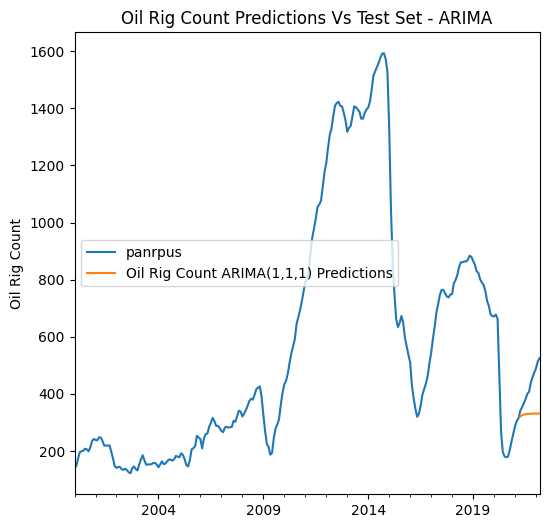

In [15]:
# Plot predictions against known values
title = 'Oil Rig Count Predictions Vs Test Set - ARIMA'
ylabel = 'Oil Rig Count'
xlabel = ''

ax = oil_ml_set[oil_rig_count].loc['2000':].plot(
    legend=True,
    title=title
    )
oil_predictions.plot(legend=True)
ax.autoscale(axis='x', tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)

#### Evaluation Metrics

In [16]:
RMSE = rmse(oil_ml_set[oil_rig_count].loc[test_oil.index.min():], oil_predictions)
MSE1 = mse(oil_ml_set[oil_rig_count].loc[test_oil.index.min():],oil_predictions)
MAE1 = meanabs(oil_ml_set[oil_rig_count].loc[test_oil.index.min():],oil_predictions)

print(f"""Oil Rig ARIMA({p_oil},{d_oil},{q_oil})
      RMSE: {RMSE:.3f}, 
      MSE: {MSE1:.3f}, 
      MAE: {MAE1:.3f}\n
Oil Rig Mean Value: {oil_ml_set[oil_rig_count][-nobs].mean():.3f}
Oil Rig Std Value: {oil_ml_set[oil_rig_count][-nobs].std():.3f}
Oil Rig Percent Change: {RMSE/oil_ml_set[oil_rig_count][-nobs].mean()*100:.3f}%
""")

Oil Rig ARIMA(1,1,1)
      RMSE: 115.872, 
      MSE: 13426.369, 
      MAE: 100.116

Oil Rig Mean Value: 341.000
Oil Rig Std Value: 0.000
Oil Rig Percent Change: 33.980%



#### Cross Validation

In [17]:
tscv = TimeSeriesSplit(n_splits=10, test_size=12)

RMSE_oil = []
MSE_oil = []
MAE_oil = []

for train_index, test_index in tscv.split(oil_ml_set[oil_rig_count]):
    
    print("TRAIN:", len(train_index), "TEST:", len(test_index))

    train_oil, test_oil = oil_ml_set[oil_rig_count][train_index], oil_ml_set[oil_rig_count][test_index]
    oil_model = ARIMA(train_oil,order=(p_oil, d_oil, q_oil))
    oil_results = oil_model.fit()
    start = len(train_oil)
    end = len(train_oil) + len(test_oil) - 1
    oil_predictions = oil_results.predict(
        start=start,
        end=end,
        dynamic=False,
        typ='levels'
    ).rename(f'Oil Rig Count ARIMA({p_oil},{d_oil},{q_oil}) Predictions')

    RMSE_oil.append('{:.3f}'.format(
        rmse(
            oil_ml_set.loc[
                oil_ml_set.index[test_index], 
                oil_rig_count
                ], 
            oil_predictions
            )
        )
    )

    MSE_oil.append('{:.3f}'.format(
        mse(
            oil_ml_set.loc[
                oil_ml_set.index[test_index], 
                oil_rig_count
                ], 
            oil_predictions
            )
        )
    )

    MAE_oil.append('{:.3f}'.format(
        meanabs(
            oil_ml_set.loc[
                oil_ml_set.index[test_index], 
                oil_rig_count
                ], 
            oil_predictions
            )
        )
    )

RMSE_oil = np.array(RMSE_oil).astype('float')
MSE_oil = np.array(MSE_oil).astype('float')
MAE_oil = np.array(MAE_oil).astype('float')
print(f"""\n10-fold Cross Validation Oil Rig Count
            
    RMSE: {RMSE_oil.mean():.3f}, 
    MSE: {MSE_oil.mean():.3f}, 
    MAE: {MAE_oil.mean():.3f}\n
    Oil Rig Mean Value: {oil_ml_set[oil_rig_count][-nobs].mean():.3f}
    Oil Rig Std Value: {oil_ml_set[oil_rig_count][-nobs].std():.3f}
    Oil Rig Percent Change: {RMSE_oil.mean()/oil_ml_set[oil_rig_count][-nobs].mean()*100:.3f}%

    """)


TRAIN: 147 TEST: 12
TRAIN: 159 TEST: 12
TRAIN: 171 TEST: 12
TRAIN: 183 TEST: 12
TRAIN: 195 TEST: 12
TRAIN: 207 TEST: 12
TRAIN: 219 TEST: 12
TRAIN: 231 TEST: 12
TRAIN: 243 TEST: 12
TRAIN: 255 TEST: 12

10-fold Cross Validation Oil Rig Count

    RMSE: 126.449, 
    MSE: 26348.421, 
    MAE: 103.978

    Oil Rig Mean Value: 341.000
    Oil Rig Std Value: 0.000
    Oil Rig Percent Change: 37.082%

    


#### Forecast Real Future

Fit Model with 100% of Data and forecast Real Future

In [18]:
startTime = time.time()
oil_model = ARIMA(oil_ml_set[oil_rig_count], order=(p_oil, d_oil, q_oil))
oil_results = oil_model.fit()

In [19]:
start=len(oil_ml_set)
end=len(oil_ml_set) + nobs
oil_predictions = oil_results.predict(
    start=start,
    end=end,
    dynamic=False,
    typ='levels'
).rename(f'Oil Rig Count ARIMA({p_oil},{d_oil},{q_oil}) Predictions')

executionTime = (time.time() - startTime)
print('Execution time in seconds: ' + str(executionTime))

Execution time in seconds: 87.46078419685364


[Text(0.5, 0, ''), Text(0, 0.5, 'Oil Rig Count')]

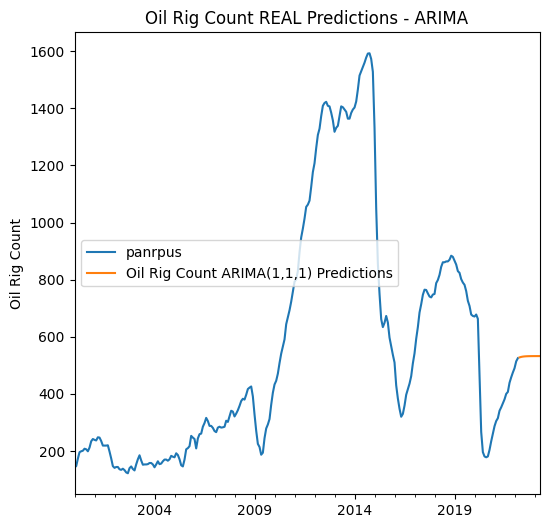

In [20]:
# Plot predictions against known values
title = 'Oil Rig Count REAL Predictions - ARIMA'
ylabel = 'Oil Rig Count'
xlabel = ''

ax = oil_ml_set[oil_rig_count].loc['2000':].plot(legend=True, title=title)
oil_predictions.plot(legend=True)
ax.autoscale(axis='x', tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)

### Gas Rig Count Modelling

In [56]:
gas_rig_count = conn.sql(
    Path("../src/feature_engineering_sql_scripts/gas_features/gas_rigs.sql").read_text()
).fetchone()[0].lower()

In [57]:
# What are the attributes of the dataset?
series_mapping_gas = conn.sql(f"""
    SELECT 
        LOWER(msn) AS msn
        ,series_description
        ,unit
    FROM pg.silver.v_total_energy_series
    WHERE msn IN ({", ".join([f"'{col.upper()}'" for col in gas_ml_set.columns])})
    """)

display(series_mapping_gas.df())

,msn,series_description,unit
0,ngtwpus,"Wells Drilled, Natural Gas in Number",Number
1,mmiceus,"Motor Gasoline, Excluding Ethanol, Industrial Sector CO2 Emissions in Million Metric Tons of Carbon Dioxide",Million Metric Tons of Carbon Dioxide
2,mgwhuus,Average Refiner Price of Finished Motor Gasoline for Resale in Dollars per Gallon Excluding Taxes,Dollars per Gallon Excluding Taxes
3,rfaceus,Residual Fuel Oil Transportation Sector CO2 Emissions in Million Metric Tons of Carbon Dioxide,Million Metric Tons of Carbon Dioxide
4,ojeibus,"Other Fossil Gases Consumption for Electricity Generation and Useful Thermal Output, Electric Power Sector in Trillion Btu",Trillion Btu
5,ruucuus,"Unleaded Regular Gasoline, U.S. City Average Retail Price in Dollars per Gallon Including Taxes",Dollars per Gallon Including Taxes
6,dmtceus,"Distillate Fuel Oil, Excluding Biodiesel, CO2 Emissions in Million Metric Tons of Carbon Dioxide",Million Metric Tons of Carbon Dioxide
7,jfaceus,Jet Fuel Transportation Sector CO2 Emissions in Million Metric Tons of Carbon Dioxide,Million Metric Tons of Carbon Dioxide
8,mgtcuus,Average Refiner Price of Finished Motor Gasoline to End Users in Dollars per Gallon Excluding Taxes,Dollars per Gallon Excluding Taxes
9,avtceus,Aviation Gasoline CO2 Emissions in Million Metric Tons of Carbon Dioxide,Million Metric Tons of Carbon Dioxide


In [58]:
# Number of observations
nobs = 12 # For 12 months?

In [59]:
stepwise_fit = auto_arima(
    gas_ml_set[gas_rig_count], 
    start_p=0, 
    start_q=0,
    max_p=6,
    max_q=3,
    m=nobs,
    seasonal=True,
    d=None,
    trace=True,
    error_action='ignore',              # Ignore orders that don't work
    suppress_warnings=True,             # Suppress convergence warnings
    stepwise=True                       # Set to stepwise    
    )

p_gas, d_gas, q_gas = stepwise_fit.order
print(f"Optimal p: {p_gas}, d: {d_gas}, q: {q_gas}")

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=2603.269, Time=0.25 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2600.984, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=2395.894, Time=0.23 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=2476.405, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2599.895, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=2394.167, Time=0.04 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=2395.894, Time=0.12 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=2397.894, Time=0.15 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=2395.850, Time=0.07 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=2395.879, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=2474.480, Time=0.06 sec
 ARIMA(2,1,1)(0,0,0)[12] intercept   : AIC=2395.312, Time=0.08 sec
 ARIMA(1,1,0)(0,0,0)[12]             : AIC=2392.308, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12]             : AIC=2394.020, Time=0.06 sec
 ARIMA(1,1,0)(0,0,1

Train/ Test Split

* Evaluate the model forecasting 12 months ahead (1 year)
* Train test split. Test df will have 12 data points

In [60]:
train_gas = gas_ml_set.iloc[:len(gas_ml_set)-nobs]
test_gas = gas_ml_set.iloc[len(gas_ml_set)-nobs:]

Fit ARIMA Model

In [61]:
gas_model = ARIMA(train_gas[gas_rig_count], order=(p_gas, d_gas, q_gas))
gas_results = gas_model.fit()
print(gas_results.summary())

                               SARIMAX Results                                
Dep. Variable:                ngnrpus   No. Observations:                  255
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -1145.868
Date:                Sat, 06 Jun 2026   AIC                           2295.737
Time:                        09:16:38   BIC                           2302.812
Sample:                    01-01-2000   HQIC                          2298.583
                         - 03-01-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7370      0.024     30.922      0.000       0.690       0.784
sigma2       483.7471     26.237     18.438      0.000     432.324     535.170
Ljung-Box (L1) (Q):                   0.14   Jarque-

#### Generate Forecast Values and Plot Results

In [62]:
# 12 Month Forecast
start = len(train_gas)
end = len(train_gas) + len(test_gas) - 1
gas_predictions = gas_results.predict(
    start=start,
    end=end,
    dynamic=False,
    typ='levels'
).rename(f'Gas Rig Count ARIMA({p_gas},{d_gas},{q_gas}) Predictions')

[Text(0.5, 0, ''), Text(0, 0.5, 'Gas Rig Count')]

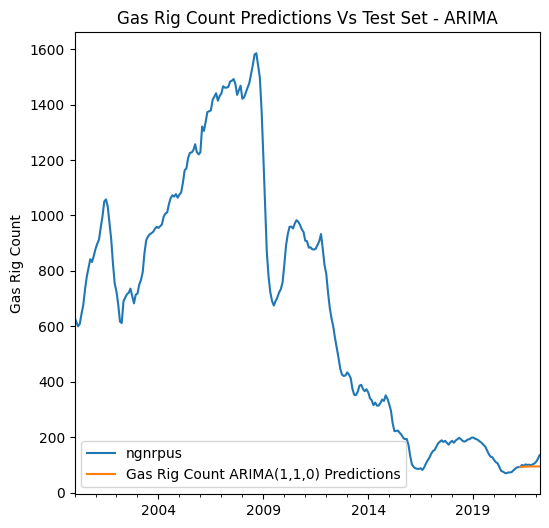

In [63]:
# Plot predictions against known values
title = 'Gas Rig Count Predictions Vs Test Set - ARIMA'
ylabel = 'Gas Rig Count'
xlabel = ''

ax = gas_ml_set[gas_rig_count].loc['2000':].plot(
    legend=True,
    title=title
    )
gas_predictions.plot(legend=True)
ax.autoscale(axis='x', tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)